In [14]:
include("copper.jl");

# Introduction

I have formatted this document as a Julia notebook because that makes it easy to add new things as we
think of them and helps me remember the algorithmic parameters I used to make the plots.

Here are some results for the methods in Lei's report. These figures
make these points.

 - Lei's prediction of convergene behavior, q-linear followed by
stagnation, is clearly validated by the results.
 - For this problem, preconditioning allows one to increase the
stepsize and reach the target error in fewer iterations.
 - Anderson acceleration is very useful for the preconditioned problem.
 - The two-stage method performs as predicted and the residual and
error histories are smoother than for Algorithm 1. However, Algorithm 2
is no more efficient because each iteration needs two gradient evaluations.

We consider the PDE problem from our paper.
We use a spatial mesh width of $h = 1/16$ in most of these examples.
The unpreconditioned iteration performs worse with smaller $h$ and
the preconditioned iteration does not. This is in line with the
estimates in our papers.

For the unpreconditioned iterations we use $\tau = \tau_0 h^2$ for stability and the curves conform to the value of $\tau_0$. For
the precondtioned iteration we use $\tau = \tau_0$ so the steps
are much larger.
In fact, the preconditioned iteration uses stepsizes far larger that I would
expect to be able to resolve the solution. I would expect the error to
be $O(\tau)$ at best, but it is much better than that.

# Results for Algorithm 1

## Study of varying $\tau$ with $\alpha$ fixed.

We make several figures to show the residual and error histories. The
residual seems to be a useful surrogate for the error and could be used
as a termination criterion, but is much noiser when the error is small.
This is reasonable and we might want to terminate before the noise becomes
large.

The first plot has $h=1/16$, $\alpha=.5$, and varies $\tau_0$. This is an unpreconditioned case so 
$\tau = \tau_0 h^2$

Ex 1; Precond = false; Fixed alpha = 0.5; vary tau


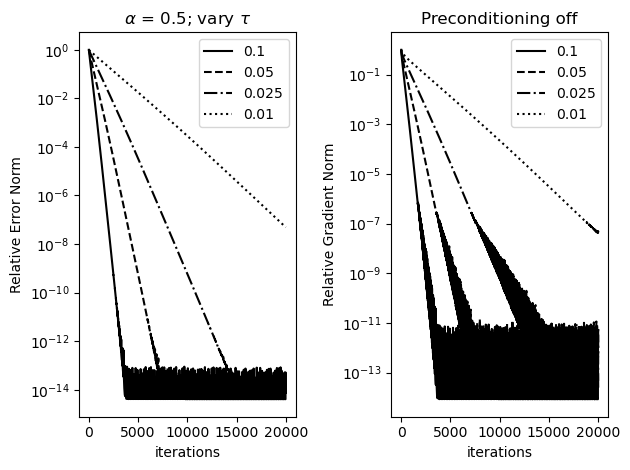

In [15]:
tau_test_copper(15);

When we add preconditioning we reach the error target in many fewer
iterations. Note the difference in the scale of the horozontal axis

Ex 1; Precond = true; Fixed alpha = 0.5; vary tau


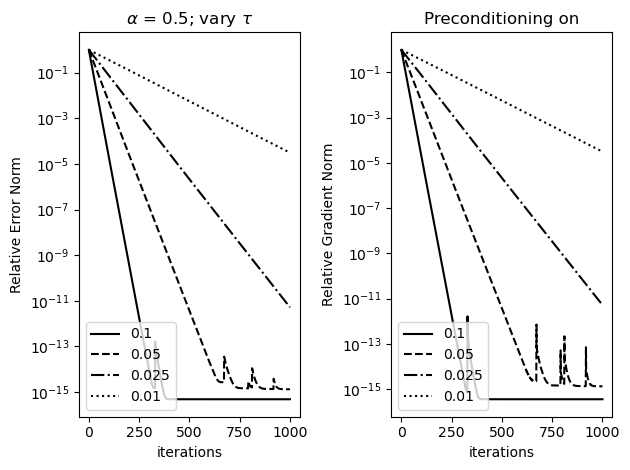

In [16]:
tau_test_copper(15; precond=true, maxit=1000);

If we decrease the mesh width to $h=1/32$ the performance of the
preconditioned iteration essentially does not change
as you can see in the next figure. The iteration histories become smoother though.

Ex 1; Precond = true; Fixed alpha = 0.5; vary tau


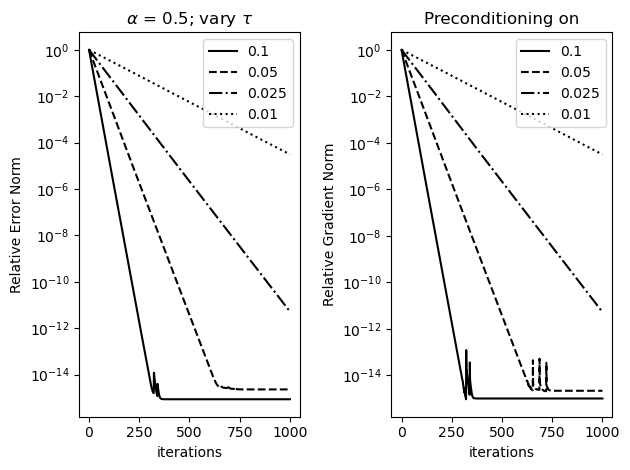

In [17]:
tau_test_copper(31; precond=true, maxit=1000);

## Varying $\alpha$ with $\tau$  fixed.

The experiments are similar. We consider cases with and without preconditioning and show that the results
are independent of the mesh size if we precondition. The results are consistent with the theory and
show that for a fixed $\tau$ the iteration will stagnate earlier as $\alpha$ decreases.

So we start with $h=1/16$ and no preconditioning. For the unpreconditioned case we fix $\tau_0 = .1$ and
$\tau=\tau_0 h^2$. With preconditioning we can use $\tau=\tau_0=.1$.

Ex 1; Precond = false; Fixed tau = 0.1; vary alpha


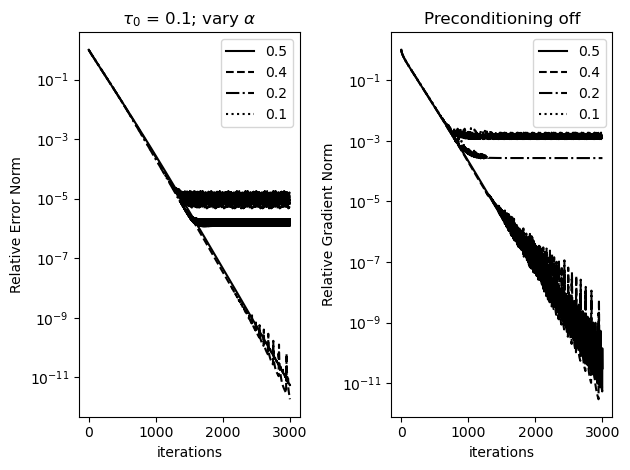

In [18]:
alpha_test_copper(15; maxit=3000);

If we precondtion we need fewer iterations, as the theory predicts, but the effect of $\alpha$ on stagnation 
is the same. The oscillations after stagnation are a bit more extreme for the larger values of $\alpha$. I do not understand why.

Ex 1; Precond = true; Fixed tau = 0.1; vary alpha


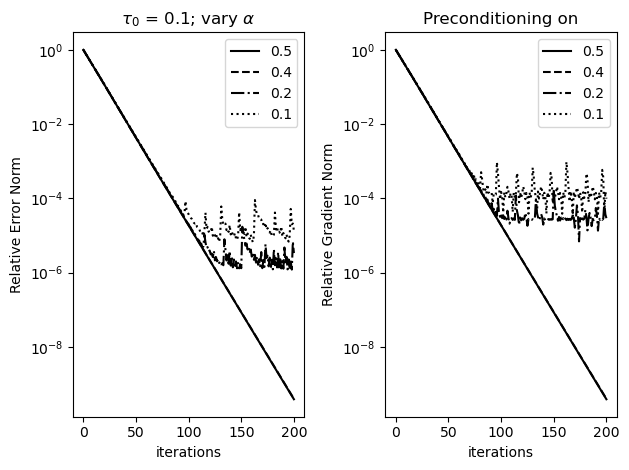

In [19]:
alpha_test_copper(15; maxit=200, precond=true);

When we reduce $h$ to $1/31$, the the iteration is similar

Ex 1; Precond = true; Fixed tau = 0.1; vary alpha


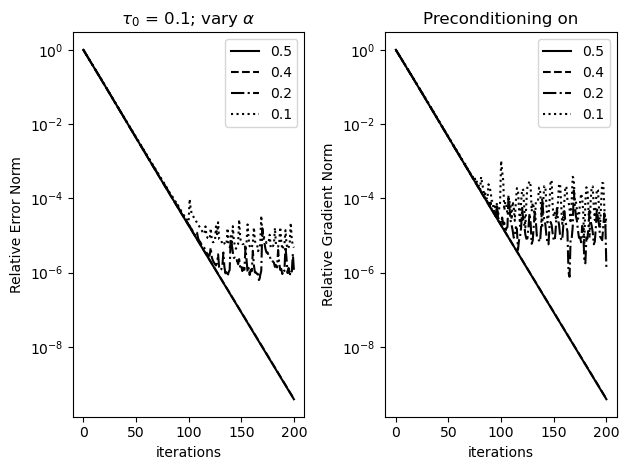

In [20]:
alpha_test_copper(31; maxit=200, precond=true);

# Results for Algorithm 2

## Varying $\tau$ with $\alpha$ fixed

We repeat the experiments for algorithm 2 and see similar results.
We confirm Lei's convergence rate predicitions and see that
preconditioning works as expected. Algorithm 2 also smooths out the
oscilations in the errors and gradient norms. However, it is not
more efficient since each iteration requires two gradient evaluations.

The next figure has the results without preconditioning.

Ex 1; Precond = false; Fixed alpha = 0.5; vary tau


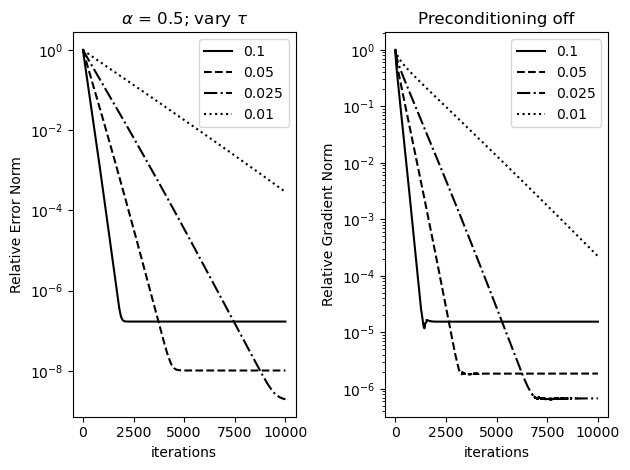

In [21]:
tau_test_copper(15; algfun=alg2ge1, maxit=10000);

The preconditioned results are next.

Ex 1; Precond = true; Fixed alpha = 0.5; vary tau


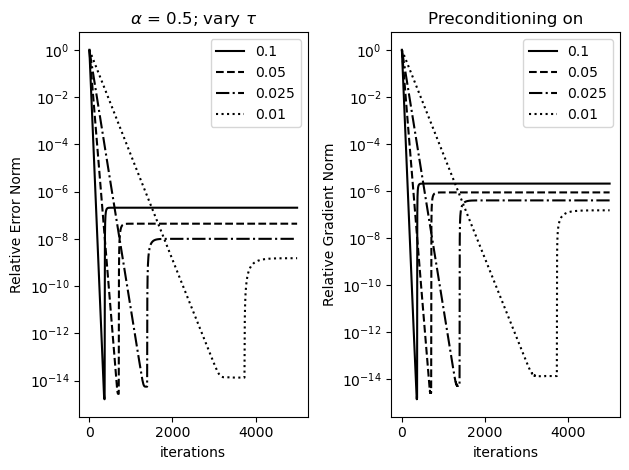

In [22]:
tau_test_copper(15; algfun=alg2ge1, precond=true, maxit=5000);

The results for $h=1/32$ are similar.

Ex 1; Precond = true; Fixed alpha = 0.5; vary tau


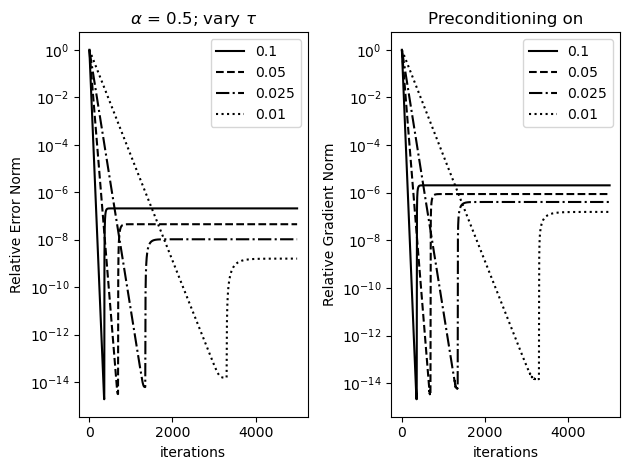

In [23]:
tau_test_copper(31; algfun=alg2ge1, precond=true, maxit=5000);

## Varying $\alpha$ with $\tau$ fixed

The figures report the same experiments as for Algorithm 1. We begin with the unpreconditioned case.

Ex 1; Precond = false; Fixed tau = 0.1; vary alpha


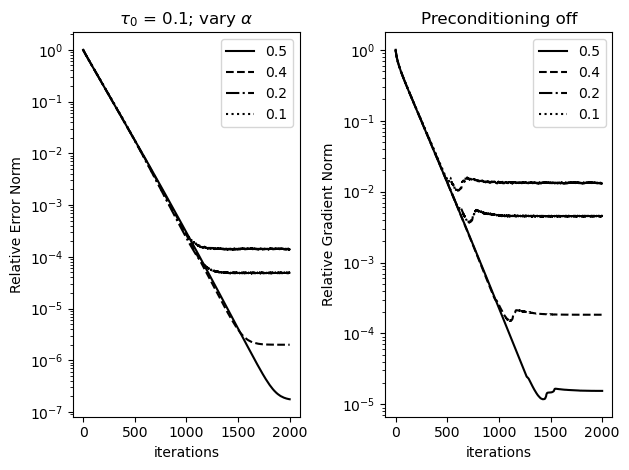

In [24]:
alpha_test_copper(15; maxit=2000, algfun=alg2ge1);

Now with preconditioning.

Ex 1; Precond = true; Fixed tau = 0.1; vary alpha


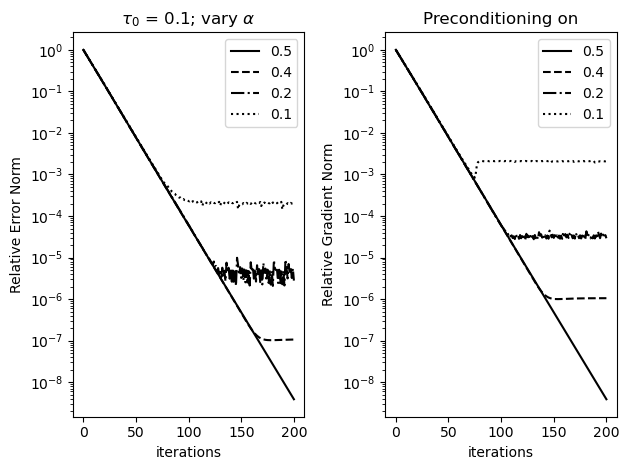

In [25]:
alpha_test_copper(15; maxit=200, algfun=alg2ge1, precond=true);